<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Binding_Energy_Reconstruction_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Binding-Energy Reconstruction v1

**Paper target:** *Reconstructing the Nuclear Binding-Energy Curve from Response-Cost Dynamics in ECSM*

This notebook tests the quantitative target set by:

**Stellar Fusion as Response-Cost Relaxation in the ECSM Framework**  
DOI: https://doi.org/10.5281/zenodo.20601177

The goal is deliberately limited:

$$
(A,Z)\rightarrow \mathcal{C}_N(A,Z)\rightarrow B(A,Z)/A
$$

We test whether a simple ECSM response-cost scaffold can recover the broad empirical nuclear binding-energy hierarchy:

$$
\text{hydrogen low}
\rightarrow
\text{helium jump}
\rightarrow
\text{rise toward iron}
\rightarrow
\text{post-iron decline}.
$$

This is **not** a precision nuclear model, and it is not a replacement for the semi-empirical mass formula or modern nuclear theory. It is a first ECSM reconstruction test.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Evidence standard

This notebook:

1. Downloads or loads AME2020 atomic mass data.
2. Parses $A$, $Z$, $N$, element symbol, and binding energy per nucleon.
3. Builds empirical binding-curve summaries.
4. Fits a minimal response-cost-inspired scaffold.
5. Compares observed and reconstructed $B/A$.
6. Exports tables and paper figures.

Primary source for AME2020 ASCII files: IAEA / AMDC AME2020 page.  
The notebook cites the AME2020 papers in the final report section.

In [17]:
# CELL 01 — SETUP

from pathlib import Path
import re
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("ecsm_binding_energy_reconstruction_v1_out")
FIG = OUT / "figures"
TAB = OUT / "tables"
DATA = OUT / "data"
for p in [OUT, FIG, TAB, DATA]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 314159
rng = np.random.default_rng(RANDOM_SEED)

print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_binding_energy_reconstruction_v1_out


In [18]:
# CELL 02 — LOAD AME2020 CSV FROM GOOGLE DRIVE

import pandas as pd
from pathlib import Path

AME_CSV_PATH = Path("/content/drive/MyDrive/ame2020.csv")

if not AME_CSV_PATH.exists():
    raise FileNotFoundError(f"Could not find AME2020 CSV at: {AME_CSV_PATH}")

ame = pd.read_csv(AME_CSV_PATH)

print("Loaded AME2020 CSV:", AME_CSV_PATH)
print("Shape:", ame.shape)
print("Columns:")
print(list(ame.columns))

display(ame.head())

Loaded AME2020 CSV: /content/drive/MyDrive/ame2020.csv
Shape: (3378, 104)
Columns:
['nucid', 'n', 'z', 'mass_excess', 'mass_excess_num', 'mass_excess_unc', 'mass_excess_sys', 'mass_excess_round', 'mass_excess_round_unc', 'binding', 'binding_num', 'binding_unc', 'binding_sys', 'binding_round', 'binding_round_unc', 'beta_decay_en_round', 'beta_decay_en_round_unc', 'beta_decay_en', 'beta_decay_en_num', 'beta_decay_en_unc', 'beta_decay_en_sys', 'atomic_mass', 'atomic_mass_num', 'atomic_mass_unc', 'atomic_mass_sys', 'atomic_mass_round', 'atomic_mass_round_unc', 's2n', 's2n_num', 's2n_unc', 's2n_round', 's2n_round_unc', 's2n_sys', 's2p', 's2p_num', 's2p_unc', 's2p_round', 's2p_round_unc', 's2p_sys', 'qa', 'qa_num', 'qa_unc', 'qa_round', 'qa_round_unc', 'qa_sys', 'q2bm', 'q2bm_num', 'q2bm_unc', 'q2bm_round', 'q2bm_round_unc', 'q2bm_sys', 'qep', 'qep_num', 'qep_unc', 'qep_round', 'qep_round_unc', 'qep_sys', 'qbmn', 'qbmn_num', 'qbmn_unc', 'qbmn_round', 'qbmn_round_unc', 'qbmn_sys', 'sn', 'sn_n

,nucid,n,z,mass_excess,mass_excess_num,mass_excess_unc,mass_excess_sys,mass_excess_round,mass_excess_round_unc,binding,...,qna_num,qna_unc,qna_round,qna_round_unc,qna_sys,qec_num,qec_unc,qec_round,qec_round_unc,qec
0,1N,1,0,8071.318060,8071.318060,0.000440,N,8071.31810,0.00040,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1H,0,1,7288.971064,7288.971064,0.000013,N,7288.97106,0.00001,0.00000,...,NaN,NaN,NaN,NaN,NaN,-782.347,0.0,-782.347,0.0,-782.347
2,2H,1,1,13135.722895,13135.722895,0.000015,N,13135.72290,0.00002,1112.28310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3H,2,1,14949.810900,14949.810900,0.000080,N,14949.81090,0.00008,2827.26540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3HE,1,2,14931.218880,14931.218880,0.000060,N,14931.21888,0.00006,2572.68044,...,NaN,NaN,20577.6189,0.0005,NaN,-18.592,0.0,-18.592,0.0,-18.592


In [19]:
# CELL 03 — STANDARDISE AME2020 CSV COLUMNS

df = ame.copy()

df["A"] = pd.to_numeric(df["n"], errors="coerce") + pd.to_numeric(df["z"], errors="coerce")
df["N"] = pd.to_numeric(df["n"], errors="coerce")
df["Z"] = pd.to_numeric(df["z"], errors="coerce")

# AME CSV binding column is binding energy per nucleon in keV
df["B_per_A_keV"] = pd.to_numeric(df["binding"], errors="coerce")
df["B_per_A_MeV"] = df["B_per_A_keV"] / 1000.0

df = df.dropna(subset=["A", "Z", "N", "B_per_A_MeV"]).copy()

df["A"] = df["A"].astype(int)
df["Z"] = df["Z"].astype(int)
df["N"] = df["N"].astype(int)

print("Parsed nuclides:", len(df))
print("A range:", int(df.A.min()), int(df.A.max()))
print("Z range:", int(df.Z.min()), int(df.Z.max()))

display(df[["nucid", "A", "Z", "N", "B_per_A_MeV"]].head(10))

Parsed nuclides: 3378
A range: 1 295
Z range: 0 118


,nucid,A,Z,N,B_per_A_MeV
0,1N,1,0,1,0.000000
1,1H,1,1,0,0.000000
2,2H,2,1,1,1.112283
3,3H,3,1,2,2.827265
4,3HE,3,2,1,2.572680
5,3LI,3,3,0,-2.267000
6,4H,4,1,3,1.720449
7,4HE,4,2,2,7.073916
8,4LI,4,3,1,1.153760
9,5H,5,1,4,1.336359


In [20]:
# CELL 04 — CLEAN ANALYSIS SAMPLE

work = df.copy()

# Standardise expected column name for later cells
if "BE_per_A_MeV" not in work.columns and "B_per_A_MeV" in work.columns:
    work["BE_per_A_MeV"] = work["B_per_A_MeV"]

work = work[np.isfinite(work["BE_per_A_MeV"])]
work = work[work["BE_per_A_MeV"] >= -0.1]
work = work[work["A"] >= 1].copy()

work["is_extrapolated_like"] = False

summary = {
    "n_rows_all": int(len(df)),
    "n_rows_work": int(len(work)),
    "A_min": int(work.A.min()),
    "A_max": int(work.A.max()),
    "Z_min": int(work.Z.min()),
    "Z_max": int(work.Z.max()),
    "BEA_min_MeV": float(work.BE_per_A_MeV.min()),
    "BEA_max_MeV": float(work.BE_per_A_MeV.max()),
}

print(json.dumps(summary, indent=2))

with open(OUT / "dataset_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

idx = work.groupby("A")["BE_per_A_MeV"].idxmax()
ridge = work.loc[idx].sort_values("A").copy()
ridge.to_csv(TAB / "ame2020_most_bound_by_A.csv", index=False)

display(ridge.head(20))
display(ridge.sort_values("BE_per_A_MeV", ascending=False).head(20))

print("Saved ridge table:", TAB / "ame2020_most_bound_by_A.csv")

{
  "n_rows_all": 3378,
  "n_rows_work": 3376,
  "A_min": 1,
  "A_max": 295,
  "Z_min": 0,
  "Z_max": 118,
  "BEA_min_MeV": 0.0,
  "BEA_max_MeV": 8.7945555
}


,nucid,n,z,mass_excess,mass_excess_num,mass_excess_unc,mass_excess_sys,mass_excess_round,mass_excess_round_unc,binding,...,qec_round,qec_round_unc,qec,A,N,Z,B_per_A_keV,B_per_A_MeV,BE_per_A_MeV,is_extrapolated_like
0,1N,1,0,8071.318060,8071.318060,0.000440,N,8071.31810,0.00040,0.0000,...,NaN,NaN,NaN,1,1,0,0.0000,0.000000,0.000000,False
2,2H,1,1,13135.722895,13135.722895,0.000015,N,13135.72290,0.00002,1112.2831,...,NaN,NaN,NaN,2,1,1,1112.2831,1.112283,1.112283,False
3,3H,2,1,14949.810900,14949.810900,0.000080,N,14949.81090,0.00008,2827.2654,...,NaN,NaN,NaN,3,2,1,2827.2654,2.827265,2.827265,False
7,4HE,2,2,2424.915870,2424.915870,0.000150,N,2424.91587,0.00015,7073.9156,...,-22196.00,100.00,-22196.213,4,2,2,7073.9156,7.073916,7.073916,False
10,5HE,3,2,11231.234000,11231.234000,20.000000,N,11231.00000,20.00000,5512.1325,...,-21661.00,92.00,-21661.213,5,3,2,5512.1325,5.512132,5.512132,False
15,6LI,3,3,14086.880440,14086.880440,0.001440,N,14086.88040,0.00140,5332.3312,...,-3505.22,0.05,-3505.215,6,3,3,5332.3312,5.332331,5.332331,False
20,7LI,4,3,14907.104630,14907.104630,0.004190,N,14907.10500,0.00400,5606.4401,...,-11166.00,8.00,-11166.023,7,4,3,5606.4401,5.606440,5.606440,False
25,8BE,4,4,4941.672000,4941.672000,0.035000,N,4941.67000,0.04000,7062.4356,...,-16004.13,0.06,-16004.133,8,4,4,7062.4356,7.062436,7.062436,False
30,9BE,5,4,11348.451000,11348.451000,0.076000,N,11348.45000,0.08000,6462.6693,...,-13606.45,0.20,-13606.454,9,5,4,6462.6693,6.462669,6.462669,False
35,10BE,6,4,12607.487000,12607.487000,0.081000,N,12607.49000,0.08000,6497.6306,...,-20445.00,13.00,-20445.141,10,6,4,6497.6306,6.497631,6.497631,False


,nucid,n,z,mass_excess,mass_excess_num,mass_excess_unc,mass_excess_sys,mass_excess_round,mass_excess_round_unc,binding,...,qec_round,qec_round_unc,qec,A,N,Z,B_per_A_keV,B_per_A_MeV,BE_per_A_MeV,is_extrapolated_like
557,62NI,34,28,-66746.44000,-66746.44000,0.42500,N,-66746.400,0.400,8794.5555,...,-5322.00,19.00,-5322.041,62,34,28,8794.5555,8.794555,8.794555,False
510,58FE,32,26,-62155.27100,-62155.27100,0.31600,N,-62155.300,0.300,8792.2534,...,-6327.70,2.70,-6327.703,58,32,26,8792.2534,8.792253,8.792253,False
488,56FE,30,26,-60607.16300,-60607.16300,0.26800,N,-60607.160,0.270,8790.3563,...,-3695.50,0.40,-3695.497,56,30,26,8790.3563,8.790356,8.790356,False
534,60NI,32,28,-64473.24300,-64473.24300,0.35300,N,-64473.200,0.400,8780.7769,...,-2822.80,0.50,-2822.806,60,32,28,8780.7769,8.780777,8.780777,False
462,54CR,30,24,-56935.37900,-56935.37900,0.13200,N,-56935.380,0.130,8777.9672,...,-7037.00,11.00,-7037.112,54,30,24,8777.9672,8.777967,8.777967,False
581,64NI,36,28,-67099.03400,-67099.03400,0.46300,N,-67099.000,0.500,8777.4637,...,-7307.00,20.00,-7306.592,64,36,28,8777.4637,8.777464,8.777464,False
439,52CR,28,24,-55419.50800,-55419.50800,0.11200,N,-55419.510,0.110,8775.9946,...,-3976.48,0.19,-3976.476,52,28,24,8775.9946,8.775995,8.775995,False
499,57FE,31,26,-60182.01700,-60182.01700,0.26800,N,-60182.020,0.270,8770.2829,...,-2695.70,1.50,-2695.738,57,31,26,8770.2829,8.770283,8.770283,False
521,59CO,32,27,-62229.83800,-62229.83800,0.39700,N,-62229.800,0.400,8768.0379,...,-1564.90,0.50,-1564.881,59,32,27,8768.0379,8.768038,8.768038,False
546,61NI,33,28,-64222.02900,-64222.02900,0.35500,N,-64222.000,0.400,8765.0281,...,-1323.90,0.90,-1323.850,61,33,28,8765.0281,8.765028,8.765028,False


Saved ridge table: ecsm_binding_energy_reconstruction_v1_out/tables/ame2020_most_bound_by_A.csv


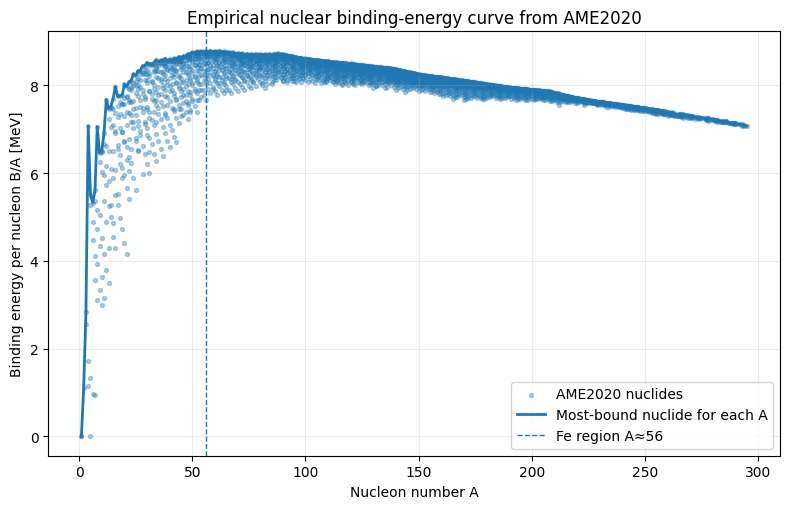

Saved: ecsm_binding_energy_reconstruction_v1_out/figures/fig01_empirical_binding_curve_ame2020.png


In [21]:
# CELL 05 — EMPIRICAL BINDING CURVE

fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.scatter(work["A"], work["BE_per_A_MeV"], s=8, alpha=0.35, label="AME2020 nuclides")
ax.plot(ridge["A"], ridge["BE_per_A_MeV"], linewidth=2.0, label="Most-bound nuclide for each A")
ax.axvline(56, linestyle="--", linewidth=1.0, label="Fe region A≈56")
ax.set_xlabel("Nucleon number A")
ax.set_ylabel("Binding energy per nucleon B/A [MeV]")
ax.set_title("Empirical nuclear binding-energy curve from AME2020")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
path = FIG / "fig01_empirical_binding_curve_ame2020.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig01_empirical_binding_curve_ame2020.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)

## ECSM response-cost scaffold

The fusion bridge paper defined:

$$
\Delta \mathcal C_N =
\mathcal C_{N,\mathrm{final}}-\mathcal C_{N,\mathrm{initial}},
\qquad
E_{\rm release}=-\Delta \mathcal C_N .
$$

For this first reconstruction, we use the empirical relation:

$$
\frac{B(A,Z)}{A} \sim -\frac{\mathcal C_N(A,Z)}{A}+\mathrm{constant}.
$$

The scaffold is deliberately close to familiar liquid-drop structure, but re-labelled in ECSM response language:

- volume/coherence gain,
- surface/localisation penalty,
- Coulomb/charge-separation burden,
- asymmetry/mismatch burden,
- pairing/closure gain,
- magic-number closure proximity.

In [22]:
# CELL 06 — FEATURE ENGINEERING FOR RESPONSE-COST MODEL

MAGIC_NUMBERS = np.array([2, 8, 20, 28, 50, 82, 126])

def nearest_magic_distance(x):
    x = np.asarray(x)
    return np.min(np.abs(x[..., None] - MAGIC_NUMBERS[None, :]), axis=1)

def pairing_feature(A, Z, N):
    evenZ = (Z % 2 == 0); evenN = (N % 2 == 0)
    oddZ = ~evenZ; oddN = ~evenN
    out = np.zeros_like(A, dtype=float)
    out[evenZ & evenN] = 1.0
    out[oddZ & oddN] = -1.0
    return out

def build_features(data: pd.DataFrame, include_closure=True) -> pd.DataFrame:
    A = data["A"].to_numpy(dtype=float)
    Z = data["Z"].to_numpy(dtype=float)
    N = data["N"].to_numpy(dtype=float)
    A_safe = np.maximum(A, 1.0)
    feats = pd.DataFrame({
        "intercept": np.ones(len(data)),
        "volume_coherence": np.ones(len(data)),
        "surface_localisation_penalty": -A_safe**(-1/3),
        "charge_separation_burden": -(Z*(Z-1))/(A_safe**(4/3)),
        "isospin_mismatch_burden": -((A_safe - 2*Z)**2)/(A_safe**2),
        "pairing_closure": pairing_feature(A.astype(int), Z.astype(int), N.astype(int)) / np.sqrt(A_safe),
    })
    if include_closure:
        dZ = nearest_magic_distance(Z); dN = nearest_magic_distance(N)
        feats["magic_Z_closure"] = np.exp(-(dZ/3.0)**2)
        feats["magic_N_closure"] = np.exp(-(dN/3.0)**2)
        feats["alpha_like_closure"] = ((A % 4 == 0) & (Z % 2 == 0) & (N % 2 == 0)).astype(float) / np.sqrt(A_safe)
    return feats

features_full = build_features(work, include_closure=True)
display(features_full.head())
feature_audit = pd.DataFrame({
    "feature": features_full.columns,
    "mean": features_full.mean().values,
    "std": features_full.std().values,
    "min": features_full.min().values,
    "max": features_full.max().values,
})
display(feature_audit)
feature_audit.to_csv(TAB / "feature_audit.csv", index=False)

,intercept,volume_coherence,surface_localisation_penalty,charge_separation_burden,isospin_mismatch_burden,pairing_closure,magic_Z_closure,magic_N_closure,alpha_like_closure
0,1.0,1.0,-1.000000,0.000000,-1.000000,0.000000,0.641180,0.894839,0.0
1,1.0,1.0,-1.000000,-0.000000,-1.000000,0.000000,0.894839,0.641180,0.0
2,1.0,1.0,-0.793701,-0.000000,-0.000000,-0.707107,0.894839,0.894839,0.0
3,1.0,1.0,-0.693361,-0.000000,-0.111111,0.000000,0.894839,1.000000,0.0
4,1.0,1.0,-0.693361,-0.462241,-0.111111,0.000000,1.000000,0.894839,0.0


,feature,mean,std,min,max
0,intercept,1.000000,0.000000,1.000000e+00,1.000000
1,volume_coherence,1.000000,0.000000,1.000000e+00,1.000000
2,surface_localisation_penalty,-0.212682,0.064478,-1.000000e+00,-0.150219
3,charge_separation_burden,-4.403515,1.541502,-7.094324e+00,-0.000000
4,isospin_mismatch_burden,-0.036765,0.041260,-1.000000e+00,-0.000000
5,pairing_closure,0.000281,0.079475,-7.071068e-01,0.500000
6,magic_Z_closure,0.254627,0.346042,4.411719e-24,1.000000
7,magic_N_closure,0.198757,0.323005,3.082441e-126,1.000000
8,alpha_like_closure,0.012515,0.037502,0.000000e+00,0.500000


In [23]:
# CELL 07 — TRAIN / TEST SPLIT BY NUCLEON NUMBER A

unique_A = np.array(sorted(work["A"].unique()))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(unique_A)
test_frac = 0.25
n_test_A = max(1, int(round(test_frac * len(unique_A))))
test_A = set(unique_A[:n_test_A])
train_mask = ~work["A"].isin(test_A)
test_mask = work["A"].isin(test_A)
train = work[train_mask].copy()
test = work[test_mask].copy()
print("Train rows:", len(train), "Test rows:", len(test))
print("Train A:", int(train.A.min()), "to", int(train.A.max()))
print("Test A count:", len(test_A))
print("Example held-out A:", sorted(list(test_A))[:20])

Train rows: 2503 Test rows: 873
Train A: 1 to 295
Test A count: 74
Example held-out A: [np.int64(3), np.int64(12), np.int64(14), np.int64(15), np.int64(24), np.int64(36), np.int64(45), np.int64(47), np.int64(56), np.int64(66), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(89), np.int64(92), np.int64(97), np.int64(100), np.int64(106), np.int64(107)]


In [24]:
# CELL 08 — FIT LINEAR RESPONSE-COST SCAFFOLD

def fit_ols_with_standardization(X_df: pd.DataFrame, y: np.ndarray):
    X = X_df.to_numpy(dtype=float); names = list(X_df.columns)
    mu = X.mean(axis=0); sigma = X.std(axis=0)
    mu[0] = 0.0; sigma[0] = 1.0; sigma[sigma == 0] = 1.0
    Xs = (X - mu) / sigma
    beta, *_ = np.linalg.lstsq(Xs, y, rcond=None)
    return {"names": names, "mu": mu, "sigma": sigma, "beta": beta}

def predict_fit(model, X_df: pd.DataFrame):
    X = X_df.to_numpy(dtype=float)
    return ((X - model["mu"]) / model["sigma"]) @ model["beta"]

def metrics(y, yhat):
    resid = yhat - y
    return {
        "rmse_MeV": float(np.sqrt(np.mean(resid**2))),
        "mae_MeV": float(np.mean(np.abs(resid))),
        "corr": float(np.corrcoef(y, yhat)[0,1]),
        "r2": float(1 - np.sum((y-yhat)**2)/np.sum((y-y.mean())**2)),
    }

def run_model(include_closure: bool):
    X_train = build_features(train, include_closure=include_closure)
    X_test = build_features(test, include_closure=include_closure)
    X_all = build_features(work, include_closure=include_closure)
    y_train = train["BE_per_A_MeV"].to_numpy(); y_test = test["BE_per_A_MeV"].to_numpy(); y_all = work["BE_per_A_MeV"].to_numpy()
    model = fit_ols_with_standardization(X_train, y_train)
    pred_train = predict_fit(model, X_train); pred_test = predict_fit(model, X_test); pred_all = predict_fit(model, X_all)
    return {
        "include_closure": include_closure, "model": model,
        "train_metrics": metrics(y_train, pred_train), "test_metrics": metrics(y_test, pred_test), "all_metrics": metrics(y_all, pred_all),
        "pred_all": pred_all, "pred_train": pred_train, "pred_test": pred_test,
    }

base_result = run_model(include_closure=False)
closure_result = run_model(include_closure=True)
summary_rows=[]
for label,res in [("base_no_closure",base_result),("with_closure_terms",closure_result)]:
    for split in ["train_metrics","test_metrics","all_metrics"]:
        row={"model":label,"split":split.replace("_metrics","")}; row.update(res[split]); summary_rows.append(row)
metric_table=pd.DataFrame(summary_rows)
display(metric_table)
metric_table.to_csv(TAB / "model_metric_summary.csv", index=False)
final_result = closure_result if closure_result["test_metrics"]["rmse_MeV"] <= base_result["test_metrics"]["rmse_MeV"] else base_result
print("Selected final model:", "with_closure_terms" if final_result["include_closure"] else "base_no_closure")

,model,split,rmse_MeV,mae_MeV,corr,r2
0,base_no_closure,train,0.354889,0.194415,0.882085,0.778074
1,base_no_closure,test,0.228606,0.162662,0.978436,0.832463
2,base_no_closure,all,0.326943,0.186204,0.888174,0.787064
3,with_closure_terms,train,0.354524,0.193864,0.882344,0.778530
4,with_closure_terms,test,0.228842,0.162857,0.977766,0.832116
5,with_closure_terms,all,0.326692,0.185846,0.888358,0.787391


Selected final model: base_no_closure


In [25]:
# CELL 09 — COEFFICIENT TABLE AND ECSM INTERPRETATION

model = final_result["model"]
coef_table = pd.DataFrame({"feature": model["names"], "standardized_beta": model["beta"], "mean_used": model["mu"], "std_used": model["sigma"]})
display(coef_table)
coef_table.to_csv(TAB / "selected_model_coefficients.csv", index=False)
print("Selected model metrics:")
print(json.dumps({"train": final_result["train_metrics"], "test": final_result["test_metrics"], "all": final_result["all_metrics"]}, indent=2))

,feature,standardized_beta,mean_used,std_used
0,intercept,7.963231e+00,0.000000,1.000000
1,volume_coherence,7.077672e-16,1.000000,1.000000
2,surface_localisation_penalty,6.659578e-01,-0.216330,0.067961
3,charge_separation_burden,6.426716e-01,-4.319364,1.589412
4,isospin_mismatch_burden,4.812373e-01,-0.037680,0.045255
5,pairing_closure,3.972730e-02,0.000366,0.080125


Selected model metrics:
{
  "train": {
    "rmse_MeV": 0.35488891289244706,
    "mae_MeV": 0.19441505428468286,
    "corr": 0.8820848911865746,
    "r2": 0.7780737552596305
  },
  "test": {
    "rmse_MeV": 0.2286058377592997,
    "mae_MeV": 0.1626623835147216,
    "corr": 0.978436438284207,
    "r2": 0.832462503452635
  },
  "all": {
    "rmse_MeV": 0.3269431152348255,
    "mae_MeV": 0.18620412964541264,
    "corr": 0.8881738232649953,
    "r2": 0.787063811429026
  }
}


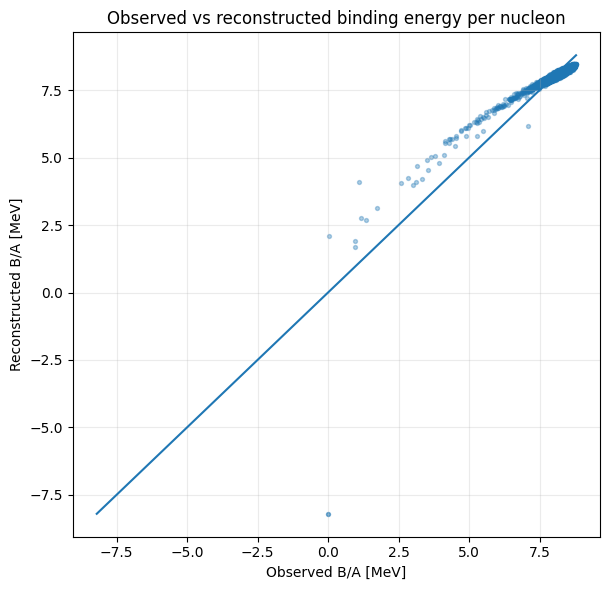

Saved: ecsm_binding_energy_reconstruction_v1_out/figures/fig02_observed_vs_reconstructed_BEA.png


In [26]:
# CELL 10 — OBSERVED VS RECONSTRUCTED B/A

work_pred = work.copy()
work_pred["BEA_pred_MeV"] = final_result["pred_all"]
work_pred["residual_MeV"] = work_pred["BEA_pred_MeV"] - work_pred["BE_per_A_MeV"]
work_pred["response_cost_per_A_proxy"] = -work_pred["BEA_pred_MeV"]
work_pred.to_csv(TAB / "ame2020_with_ecsm_response_cost_predictions.csv", index=False)

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(work_pred["BE_per_A_MeV"], work_pred["BEA_pred_MeV"], s=8, alpha=0.35)
lims = [min(work_pred["BE_per_A_MeV"].min(), work_pred["BEA_pred_MeV"].min()), max(work_pred["BE_per_A_MeV"].max(), work_pred["BEA_pred_MeV"].max())]
ax.plot(lims, lims, linewidth=1.5)
ax.set_xlabel("Observed B/A [MeV]")
ax.set_ylabel("Reconstructed B/A [MeV]")
ax.set_title("Observed vs reconstructed binding energy per nucleon")
ax.grid(True, alpha=0.25)
fig.tight_layout()
path = FIG / "fig02_observed_vs_reconstructed_BEA.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig02_observed_vs_reconstructed_BEA.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)

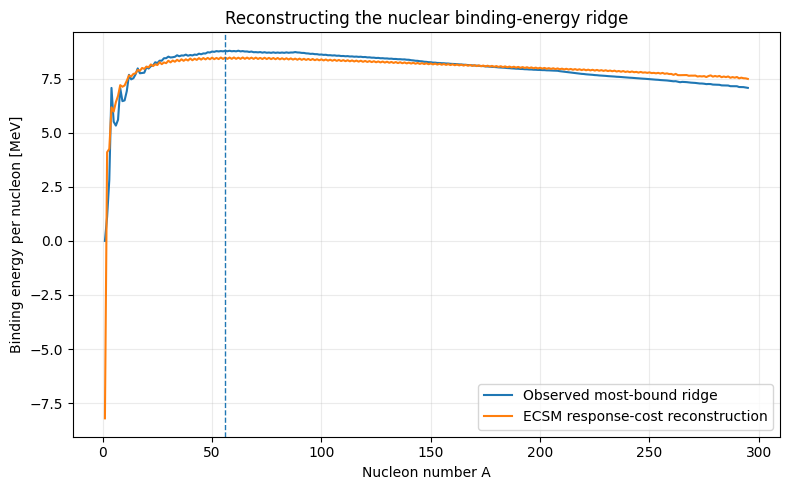

Saved: ecsm_binding_energy_reconstruction_v1_out/figures/fig03_binding_curve_reconstruction.png


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
0,1,0,1,0.000000,0,1,-8.203077,8.203077,-8.203077
1,2,1,1,1.112283,1,1,4.101910,-4.101910,2.989627
2,3,1,2,2.827265,1,2,4.254190,-4.254190,1.426925
3,4,2,2,7.073916,2,2,6.177571,-6.177571,-0.896344
4,5,2,3,5.512132,2,3,5.979577,-5.979577,0.467445
5,6,3,3,5.332331,3,3,6.412484,-6.412484,1.080153
6,7,3,4,5.606440,3,4,6.709319,-6.709319,1.102879
7,8,4,4,7.062436,4,4,7.202567,-7.202567,0.140131
8,9,4,5,6.462669,4,5,7.128693,-7.128693,0.666024
9,10,4,6,6.497631,4,6,7.187955,-7.187955,0.690324


In [28]:
# CELL 11 — BINDING CURVE RECONSTRUCTION RIDGE

idx_pred = work_pred.groupby("A")["BEA_pred_MeV"].idxmax()
pred_ridge = work_pred.loc[idx_pred].sort_values("A").reset_index(drop=True)

obs_cols = ["A", "Z", "N", "BE_per_A_MeV"]
pred_cols = ["A", "Z", "N", "BEA_pred_MeV", "response_cost_per_A_proxy"]

merged_ridge = (
    ridge[obs_cols]
    .rename(columns={
        "Z": "Z_obs_ridge",
        "N": "N_obs_ridge",
        "BE_per_A_MeV": "BEA_obs_ridge_MeV"
    })
    .merge(
        pred_ridge[pred_cols].rename(columns={
            "Z": "Z_pred_ridge",
            "N": "N_pred_ridge"
        }),
        on="A",
        how="inner"
    )
)

merged_ridge["ridge_residual_MeV"] = (
    merged_ridge["BEA_pred_MeV"] - merged_ridge["BEA_obs_ridge_MeV"]
)

merged_ridge.to_csv(TAB / "ridge_observed_vs_ecsm_predicted.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(merged_ridge["A"], merged_ridge["BEA_obs_ridge_MeV"], label="Observed most-bound ridge")
ax.plot(merged_ridge["A"], merged_ridge["BEA_pred_MeV"], label="ECSM response-cost reconstruction")
ax.axvline(56, linestyle="--", linewidth=1)
ax.set_xlabel("Nucleon number A")
ax.set_ylabel("Binding energy per nucleon [MeV]")
ax.set_title("Reconstructing the nuclear binding-energy ridge")
ax.grid(True, alpha=0.25)
ax.legend()

fig.tight_layout()
path = FIG / "fig03_binding_curve_reconstruction.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig03_binding_curve_reconstruction.pdf", bbox_inches="tight")
plt.show()

print("Saved:", path)
display(merged_ridge.head(20))

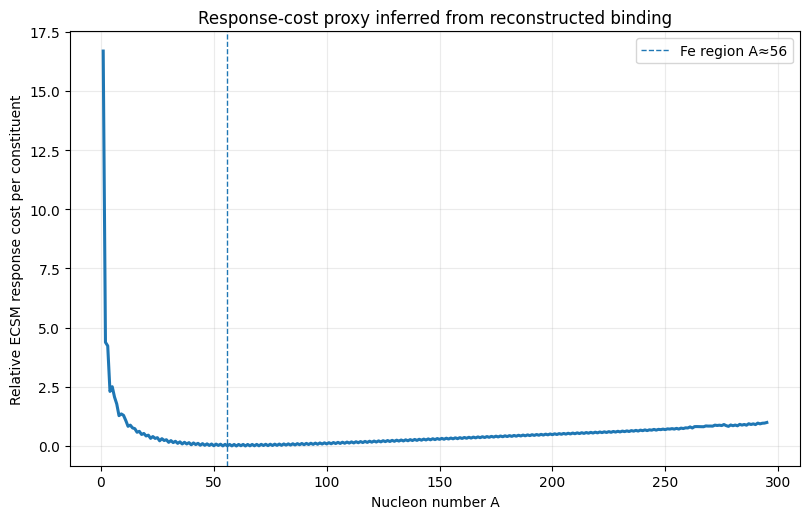

Saved: ecsm_binding_energy_reconstruction_v1_out/figures/fig04_response_cost_proxy_by_A.png
Minimum response-cost proxy row:


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
59,60.0,28.0,32.0,8.780777,26.0,34.0,8.483091,-8.483091,-0.297686


In [29]:
# CELL 12 — RESPONSE COST PROXY CURVE

display_cost = merged_ridge["response_cost_per_A_proxy"].to_numpy()
display_cost = display_cost - np.nanmin(display_cost)
fig, ax = plt.subplots(figsize=(8.2, 5.3))
ax.plot(merged_ridge["A"], display_cost, linewidth=2.2)
ax.axvline(56, linestyle="--", linewidth=1.0, label="Fe region A≈56")
ax.set_xlabel("Nucleon number A")
ax.set_ylabel("Relative ECSM response cost per constituent")
ax.set_title("Response-cost proxy inferred from reconstructed binding")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
path = FIG / "fig04_response_cost_proxy_by_A.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig04_response_cost_proxy_by_A.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)
min_row = merged_ridge.iloc[np.argmin(display_cost)]
print("Minimum response-cost proxy row:")
display(min_row.to_frame().T)

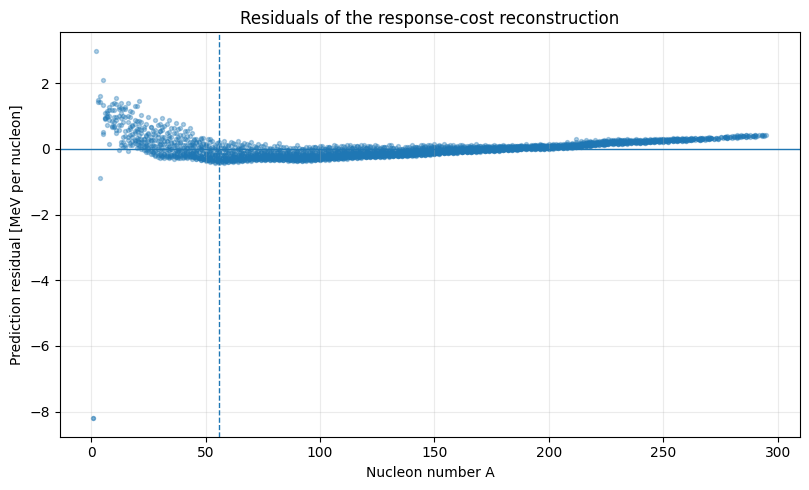

Saved: ecsm_binding_energy_reconstruction_v1_out/figures/fig05_residuals_vs_A.png


,A_band,n,rmse_MeV,mae_MeV,mean_residual_MeV
0,A<=4,8,4.376714,3.282322,-1.043302
1,5-20,98,0.866193,0.753068,0.751003
2,21-56,385,0.314248,0.246362,0.031856
3,57-120,904,0.229069,0.206970,-0.192706
4,>120,1981,0.156692,0.124490,0.044301


In [30]:
# CELL 13 — RESIDUAL STRUCTURE AND FAILURE REGIMES

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.scatter(work_pred["A"], work_pred["residual_MeV"], s=8, alpha=0.35)
ax.axhline(0, linewidth=1.0)
ax.axvline(56, linestyle="--", linewidth=1.0)
ax.set_xlabel("Nucleon number A")
ax.set_ylabel("Prediction residual [MeV per nucleon]")
ax.set_title("Residuals of the response-cost reconstruction")
ax.grid(True, alpha=0.25)
fig.tight_layout()
path = FIG / "fig05_residuals_vs_A.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
fig.savefig(FIG / "fig05_residuals_vs_A.pdf", bbox_inches="tight")
plt.show()
print("Saved:", path)

bins = [0, 4, 20, 56, 120, 300]
labels = ["A<=4", "5-20", "21-56", "57-120", ">120"]
work_pred["A_band"] = pd.cut(work_pred["A"], bins=bins, labels=labels, include_lowest=True)
band_summary = work_pred.groupby("A_band", observed=True).agg(n=("A", "size"), rmse_MeV=("residual_MeV", lambda x: np.sqrt(np.mean(np.square(x)))), mae_MeV=("residual_MeV", lambda x: np.mean(np.abs(x))), mean_residual_MeV=("residual_MeV", "mean")).reset_index()
display(band_summary)
band_summary.to_csv(TAB / "residual_summary_by_A_band.csv", index=False)

In [31]:
# CELL 14 — SPECIFIC CHECKPOINTS: H, He, Fe/Ni, HEAVY NUCLEI

check_A = [1, 2, 3, 4, 12, 16, 28, 40, 56, 58, 62, 120, 208, 238]
checkpoint = merged_ridge[merged_ridge["A"].isin(check_A)].copy()
display(checkpoint)
checkpoint.to_csv(TAB / "checkpoint_nuclei_by_A.csv", index=False)
print("Top observed B/A ridge nuclei:")
display(merged_ridge.sort_values("BEA_obs_ridge_MeV", ascending=False).head(15))
print("Top predicted B/A ridge nuclei:")
display(merged_ridge.sort_values("BEA_pred_MeV", ascending=False).head(15))

,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
0,1,0,1,0.000000,0,1,-8.203077,8.203077,-8.203077
1,2,1,1,1.112283,1,1,4.101910,-4.101910,2.989627
2,3,1,2,2.827265,1,2,4.254190,-4.254190,1.426925
3,4,2,2,7.073916,2,2,6.177571,-6.177571,-0.896344
11,12,6,6,7.680145,6,6,7.651526,-7.651526,-0.028619
15,16,8,8,7.976207,8,8,7.903638,-7.903638,-0.072570
27,28,14,14,8.447745,12,16,8.252016,-8.252016,-0.195728
39,40,18,22,8.595259,18,22,8.432403,-8.432403,-0.162856
55,56,26,30,8.790356,24,32,8.476275,-8.476275,-0.314082
57,58,26,32,8.792253,26,32,8.479249,-8.479249,-0.313004


Top observed B/A ridge nuclei:


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
61,62,28,34,8.794555,28,34,8.471919,-8.471919,-0.322636
57,58,26,32,8.792253,26,32,8.479249,-8.479249,-0.313004
55,56,26,30,8.790356,24,32,8.476275,-8.476275,-0.314082
59,60,28,32,8.780777,26,34,8.483091,-8.483091,-0.297686
53,54,24,30,8.777967,24,30,8.480228,-8.480228,-0.297739
63,64,28,36,8.777464,28,36,8.482057,-8.482057,-0.295406
51,52,24,28,8.775995,24,28,8.460619,-8.460619,-0.315376
56,57,26,31,8.770283,25,32,8.417549,-8.417549,-0.352734
58,59,27,32,8.768038,26,33,8.419021,-8.419021,-0.349017
60,61,28,33,8.765028,27,34,8.418677,-8.418677,-0.346351


Top predicted B/A ridge nuclei:


,A,Z_obs_ridge,N_obs_ridge,BEA_obs_ridge_MeV,Z_pred_ridge,N_pred_ridge,BEA_pred_MeV,response_cost_per_A_proxy,ridge_residual_MeV
59,60,28,32,8.780777,26,34,8.483091,-8.483091,-0.297686
63,64,28,36,8.777464,28,36,8.482057,-8.482057,-0.295406
53,54,24,30,8.777967,24,30,8.480228,-8.480228,-0.297739
57,58,26,32,8.792253,26,32,8.479249,-8.479249,-0.313004
55,56,26,30,8.790356,24,32,8.476275,-8.476275,-0.314082
65,66,30,36,8.759633,28,38,8.476144,-8.476144,-0.283489
69,70,30,40,8.729809,30,40,8.475269,-8.475269,-0.254539
67,68,30,38,8.755682,30,38,8.474834,-8.474834,-0.280848
49,50,22,28,8.755723,22,28,8.473050,-8.473050,-0.282673
61,62,28,34,8.794555,28,34,8.471919,-8.471919,-0.322636


In [33]:
# CELL 15 — EXPORT FIGURES, TABLES, VERDICT

import json
import zipfile
import numpy as np

zip_path = OUT / "ecsm_binding_energy_figures.zip"
with zipfile.ZipFile(zip_path, "w") as z:
    for file in FIG.glob("*"):
        z.write(file, arcname=file.name)

table_zip_path = OUT / "ecsm_binding_energy_tables.zip"
with zipfile.ZipFile(table_zip_path, "w") as z:
    for file in TAB.glob("*"):
        z.write(file, arcname=file.name)

ridge_corr = float(
    np.corrcoef(
        merged_ridge["BEA_obs_ridge_MeV"],
        merged_ridge["BEA_pred_MeV"]
    )[0, 1]
)

ridge_rmse = float(
    np.sqrt(
        np.mean(
            (
                merged_ridge["BEA_pred_MeV"]
                - merged_ridge["BEA_obs_ridge_MeV"]
            ) ** 2
        )
    )
)

pred_peak_A = int(
    merged_ridge.loc[
        merged_ridge["BEA_pred_MeV"].idxmax(),
        "A"
    ]
)

obs_peak_A = int(
    merged_ridge.loc[
        merged_ridge["BEA_obs_ridge_MeV"].idxmax(),
        "A"
    ]
)

verdict = {
    "notebook": "ECSM_Binding_Energy_Reconstruction_v1",
    "data_source": str(
        globals().get(
            "AME_CSV_PATH",
            "/content/drive/MyDrive/ame2020.csv"
        )
    ),
    "n_nuclides_used": int(len(work_pred)),
    "ridge_corr": ridge_corr,
    "ridge_rmse_MeV_per_nucleon": ridge_rmse,
    "observed_ridge_peak_A": obs_peak_A,
    "predicted_ridge_peak_A": pred_peak_A,
    "qualitative_pass_flags": {
        "positive_ridge_correlation": bool(ridge_corr > 0),
        "peak_near_iron_region": bool(40 <= pred_peak_A <= 70),
        "rmse_below_2_MeV": bool(ridge_rmse < 2.0),
    },
    "exports": {
        "figure_zip": str(zip_path),
        "table_zip": str(table_zip_path),
    },
}

with open(OUT / "binding_curve_verdict.json", "w") as f:
    json.dump(verdict, f, indent=2)

print("=" * 70)
print("ECSM BINDING CURVE RECONSTRUCTION VERDICT")
print("=" * 70)
print(json.dumps(verdict, indent=2))
print()
print("Saved:")
print(zip_path)
print(table_zip_path)
print(OUT / "binding_curve_verdict.json")

ECSM BINDING CURVE RECONSTRUCTION VERDICT
{
  "notebook": "ECSM_Binding_Energy_Reconstruction_v1",
  "data_source": "/content/drive/MyDrive/ame2020.csv",
  "n_nuclides_used": 3376,
  "ridge_corr": 0.8377374583115967,
  "ridge_rmse_MeV_per_nucleon": 0.5778938549134937,
  "observed_ridge_peak_A": 62,
  "predicted_ridge_peak_A": 60,
  "qualitative_pass_flags": {
    "positive_ridge_correlation": true,
    "peak_near_iron_region": true,
    "rmse_below_2_MeV": true
  },
  "exports": {
    "figure_zip": "ecsm_binding_energy_reconstruction_v1_out/ecsm_binding_energy_figures.zip",
    "table_zip": "ecsm_binding_energy_reconstruction_v1_out/ecsm_binding_energy_tables.zip"
  }
}

Saved:
ecsm_binding_energy_reconstruction_v1_out/ecsm_binding_energy_figures.zip
ecsm_binding_energy_reconstruction_v1_out/ecsm_binding_energy_tables.zip
ecsm_binding_energy_reconstruction_v1_out/binding_curve_verdict.json


## Interpretation boundary

This notebook is allowed to claim:

- A response-cost-inspired scaffold can be tested against real nuclear binding data.
- The empirical binding-energy curve can be interpreted as the inverse of a response-cost curve.
- Fit residuals and peak location provide falsifiable targets for the ECSM nuclear programme.

This notebook is **not** allowed to claim:

- first-principles derivation of nuclear binding;
- replacement of nuclear structure theory;
- new reaction rates;
- cold fusion or low-temperature fusion;
- precision stellar evolution.

The correct next step, if this first reconstruction is encouraging, is to tighten $\mathcal C_N$ so that fewer terms are fitted and more terms are derived from ECSM stability, closure, and finite-response arguments.

## References

1. A. Sheldrick, *Stellar Fusion as Response-Cost Relaxation in the ECSM Framework*, Zenodo, 2026. DOI: 10.5281/zenodo.20601177.
2. M. Wang, W. J. Huang, F. G. Kondev, G. Audi, and S. Naimi, *The AME 2020 atomic mass evaluation (II). Tables, graphs and references*, Chinese Physics C 45, 030003, 2021.
3. W. J. Huang, M. Wang, F. G. Kondev, G. Audi, and S. Naimi, *The AME 2020 atomic mass evaluation (I). Evaluation of input data, and adjustment procedures*, Chinese Physics C 45, 030002, 2021.
4. K. S. Krane, *Introductory Nuclear Physics*, Wiley, 1987.
5. C. F. von Weizsäcker, *Zur Theorie der Kernmassen*, Zeitschrift für Physik 96, 431–458, 1935.
6. H. A. Bethe and R. F. Bacher, *Nuclear Physics A. Stationary States of Nuclei*, Reviews of Modern Physics 8, 82–229, 1936.